<a href="https://colab.research.google.com/github/AlisaLeibova/ML-study/blob/main/Copy_of_HW_2_3_%D0%94%D0%B5%D1%80%D0%B5%D0%B2%D0%B0_%D0%BF%D1%80%D0%B8%D0%B9%D0%BD%D1%8F%D1%82%D1%82%D1%8F_%D1%80%D1%96%D1%88%D0%B5%D0%BD%D1%8C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

В цьому домашньому завданні ми знову працюємо з даними з нашого змагання ["Bank Customer Churn Prediction (DLU Course)"](https://www.kaggle.com/t/7c080c5d8ec64364a93cf4e8f880b6a0).

Тут ми побудуємо рішення задачі класифікації з використанням Decision Trees і зробимо новий submission на змагання на Kaggle.

В цьому ДЗ ми працюємо без pipelines, бо так буде зручніше для візуалізації і інтерпретації моделі дерева прийняття рішень. Так буває і в робочих проєктах: іноді зручніше використати sklearn.Pipelines, іноді зручніше без них. На етапі пошуку рішення (research) зручніше без пайплайнів, а з пайплайнами - коли ви відлагодили процес обробки даних і хочете поекспериментувати з різними моделями і гіперпараметрами.

**Завдання 1.**

У попередньому домашньому завданні, `HW 2.7 Логістична регресія з scikit learn.ipynb`, ми писали обробку даних для змагання. Ваше завдання зараз - за прикладом, наведеним в лекції `Майстер-клас з перенесення коду з jupyter notebook у Python модуль`, перенести попередню обробку сирих даних з вашого розв'язку ДЗ 2.7 у файл `process_bank_churn.py` в функцію `preprocess_data(...)`.

Функція `preprocess_data()` має приймати `raw_df` і вертати `X_train`, `train_targets`, `X_val`, `val_targets`, `input_cols`(перелік назв колонок, які Ви використовуєте в X), `scaler`, `encoder`, які ми потім будемо використовувати для тренування дерева прийняття рішень.


### Кроки попередньої обробки:

1. Обираємо колонки для роботи. В цьому завдання для чистоти експериментів рекомендую прибрати колонку `Surname`, так буде простіше інтрепретувати модель. Ви можете її додати вже за самостійних подальших експериментів.
2. Розбиття сирих даних на тренувальні і валідаційні.
3. Обробка категоріальних даних (one hot encoding).
4. Масштабування числових даних (було частиною попередньої обробки в попередніх завданнях). Для дерев нам не обовʼязково масштабувати ознаки, тож в коді можна зробити цю частину опціональною, додавши в `preprocess_data` параметр `scaler_numeric`, який приймає значення `True` або `False`. Це дозволить використовувати код попередньоъ обробки з різними моделями.


### Інструкції:
1. Перенесіть попередню обробку даних у файл `process_bank_churn.py`.
2. Забезпечте модулярну структуру функцій: кожна функція повинна виконувати лише одну дію, наприклад, масштабувати ознаки.
3. Додайте докстрінги до кожної функції.
4. Використовуйте typing для аргументів та значень, що повертаються функціями.
5. Передбачте обробку нових даних. Додайте спеціальну функцію `preprocess_new_data(...)`, яка приймає на вхід нові дані в вигляді pandas DataFrame та використовує вже навчені скейлер та енкодер (передані теж як аргументи фукнціх) для їх обробки. Ця функція буде корисною для обробки нових даних перед передбаченням або оцінкою моделі, коли оброблятимемо `test.csv`.

Можна і рекомендовано виконувати це завдання з ChatGPT (бажано, новіше, ніж 3.5) як було наведено у відео-прикладі, тільки **ваше додаткове завдання - розібратись з кодом, який вам згенерувала мовна модель :)**.

## В результаті цього завдання

1. Завантажте ваш готовий `process_bank_churn.py` файл на GitHub у свій репозиторій.
2. Додайте посилання на файл в репозиторії тут у ноутбуці.
3. Нижче зробіть імпорт функції `preprocess_data` з вашого модуля `process_bank_churn.py`.



https://github.com/AlisaLeibova/ML-study/blob/main/process_bank_churn.py$0

In [ ]:
from process_bank_churn import preprocess_data


In [ ]:
import sys

if "process_bank_churn" in sys.modules:
    del sys.modules["process_bank_churn"]

from process_bank_churn import preprocess_data

In [ ]:
import pandas as pd

raw_df = pd.read_csv("train.csv")

data = preprocess_data(raw_df)

print(type(data))


<class 'dict'>


In [ ]:
data['train_targets']

,Exited
7180,0.0
10393,0.0
80,0.0
3365,0.0
12236,0.0
...,...
9493,0.0
8463,0.0
8143,0.0
11512,0.0


In [ ]:
X_train = data['train_inputs']
train_targets = data['train_targets']
X_val = data['val_inputs']
val_targets = data['val_targets']

**Завдання 2.**
1. Натренуйте дерево прийняття рішень з зафіксованим `random_state` і з рештою аргументів за замовченням.
2. Виведіть area under ROC для моделі на тренувальних і тестувальних даних. Нам потрібна ця метрика, бо вона основна в змаганні. Модель ок, чи є пере- або недотренування?
3. Виведіть глибину дерева.
4. Побудуйте дерево до глибини 2 включно. Напишіть, які ознаки бачите, що є найвпливовішими тут?
5. Створіть датафрейм `importance_df` з feature importances, де в першому стовпчику `feature` - назва ознаки з нашого Х, а в другому `importance` - значення, наскільки ця ознака є важливою в побудованій моделі. Виведіть топ 10 найвпливовіших ознак разом з їх скором важливості (можна або у вигляді таблиці, або в вигляді barplot).

In [ ]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(random_state=42)

In [ ]:
model.fit(X_train, train_targets)

DecisionTreeClassifier(random_state=42)

In [ ]:
from sklearn.metrics import roc_auc_score

# Probabilities for the positive class
train_probs = model.predict_proba(X_train)[:, 1]
val_probs = model.predict_proba(X_val)[:, 1]

# ROC AUC
train_auc = roc_auc_score(train_targets, train_probs)
val_auc = roc_auc_score(val_targets, val_probs)

print(f"Train ROC AUC: {train_auc:.4f}")
print(f"Validation ROC AUC: {val_auc:.4f}")

Train ROC AUC: 1.0000
Validation ROC AUC: 0.7605


Здається, що модель ідеально вивчила навчальні приклади, але не узагальнює добре на раніше невидимі приклади. Це явище називається "перенавчання" (overfitting). Модель не ок, треба іі спробувати поліпшити.

In [ ]:
model.tree_.max_depth

23

In [ ]:
from sklearn.tree import export_text
tree_text = export_text(model, max_depth=2, feature_names=list(X_train.columns))
print(tree_text[:800])

|--- Age <= 0.46
|   |--- NumOfProducts <= 0.17
|   |   |--- Age <= 0.38
|   |   |   |--- truncated branch of depth 21
|   |   |--- Age >  0.38
|   |   |   |--- truncated branch of depth 16
|   |--- NumOfProducts >  0.17
|   |   |--- NumOfProducts <= 0.50
|   |   |   |--- truncated branch of depth 19
|   |   |--- NumOfProducts >  0.50
|   |   |   |--- truncated branch of depth 7
|--- Age >  0.46
|   |--- NumOfProducts <= 0.17
|   |   |--- IsActiveMember <= 0.50
|   |   |   |--- truncated branch of depth 15
|   |   |--- IsActiveMember >  0.50
|   |   |   |--- truncated branch of depth 18
|   |--- NumOfProducts >  0.17
|   |   |--- NumOfProducts <= 0.50
|   |   |   |--- truncated branch of depth 15
|   |   |--- NumOfProducts >  0.50
|   |   |   |--- class: 1.0



In [ ]:
model.feature_importances_.round(2)

array([0.07, 0.08, 0.07, 0.34, 0.04, 0.07, 0.17, 0.01, 0.03, 0.08, 0.01,
       0.02, 0.01, 0.01, 0.  ])

In [ ]:
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

In [ ]:
importance_df.head(10)

,feature,importance
3,Age,0.339715
6,NumOfProducts,0.168379
9,EstimatedSalary,0.075879
1,CustomerId,0.075051
0,id,0.073747
5,Balance,0.072693
2,CreditScore,0.070632
4,Tenure,0.038542
8,IsActiveMember,0.033198
11,Geography_Germany,0.015516


The most powerful features are Age and NumOfproducts

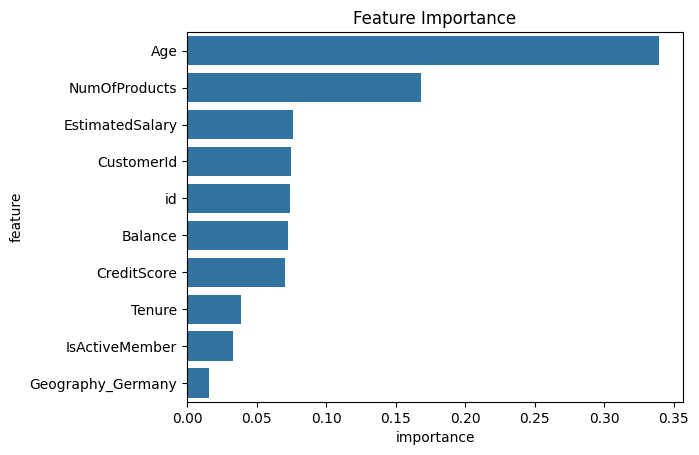

In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns
plt.title('Feature Importance')
sns.barplot(data=importance_df.head(10), x='importance', y='feature');

**Завдання 3**. Спробуйте знайти такі параметри моделі `DecisionTree` аби модель генералізувала ліпше (був вищий показник AUROC на валідаційній вибірці). Проекспериментуйте з різними значеннями параметрів `max_leaf_nodes`, `max_depth` та лишіть ті, які дають найкращий результат, разом з відповідними AUROC на тренувальній і валідаційній вибірках.

В цьому завданні спробуйте просто знайти параметри методом "тика" :)

In [ ]:
model = DecisionTreeClassifier(max_depth=5, random_state=42)
model.fit(X_train, train_targets)# Probabilities for the positive class
train_probs = model.predict_proba(X_train)[:, 1]
val_probs = model.predict_proba(X_val)[:, 1]

# ROC AUC
train_auc = roc_auc_score(train_targets, train_probs)
val_auc = roc_auc_score(val_targets, val_probs)

print(f"Train ROC AUC for new max_depth: {train_auc:.4f}")
print(f"Validation ROC AUC for new max_depth: {val_auc:.4f}")

Train ROC AUC for new max_depth: 0.9258
Validation ROC AUC for new max_depth: 0.9235


Методом "тика" найкраща модель отримується при глибині=5, все що вище, поліпщує значення трейн РОК,але погіршує валідаційні результати

In [ ]:
model = DecisionTreeClassifier(max_leaf_nodes=46, random_state=42)
model.fit(X_train, train_targets)
train_probs = model.predict_proba(X_train)[:, 1]
val_probs = model.predict_proba(X_val)[:, 1]

# ROC AUC
train_auc = roc_auc_score(train_targets, train_probs)
val_auc = roc_auc_score(val_targets, val_probs)

print(f"Train ROC AUC for new max_lead_nodes: {train_auc:.4f}")
print(f"Validation ROC AUC for max_lead_nodes: {val_auc:.4f}")
model.tree_.max_depth

Train ROC AUC for new max_lead_nodes: 0.9304
Validation ROC AUC for max_lead_nodes: 0.9217


9

Методом "тика" найкраща модель отримується при max_lead_nodes=46

**Завдання 4**. В циклі пройдіться по значенням max_depth від 1 до 20 включно, на кожній ітерації натренуйте DecisionTree модель і виміряйте AUROC на трейн і валідаційних даних.

В кінці виведіть на графік залеєність між AUROC на трейн і валідаційних даних і номером ітерації.

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score
import pandas as pd
import matplotlib.pyplot as plt


def max_depth_auc(md):
    """
    Train Decision Tree with a given max_depth
    and calculate AUROC on train and validation data.

    Args:
        md: Maximum tree depth.

    Returns:
        Dictionary with depth and AUROC scores.
    """

    model = DecisionTreeClassifier(
        max_depth=md,
        random_state=42
    )

    model.fit(X_train, train_targets)

    train_probs = model.predict_proba(X_train)[:, 1]
    val_probs = model.predict_proba(X_val)[:, 1]

    train_auc = roc_auc_score(
        train_targets,
        train_probs
    )

    val_auc = roc_auc_score(
        val_targets,
        val_probs
    )

    return {
        "Max Depth": md,
        "Training AUROC": train_auc,
        "Validation AUROC": val_auc,
    }

In [ ]:
%%time

auc_df = pd.DataFrame(
    [
        max_depth_auc(md)
        for md in range(1, 21)
    ]
)

auc_df

CPU times: user 2.59 s, sys: 2.82 ms, total: 2.59 s
Wall time: 4.07 s


,Max Depth,Training AUROC,Validation AUROC
0,1,0.744727,0.734865
1,2,0.842908,0.846496
2,3,0.897184,0.891146
3,4,0.911281,0.911264
4,5,0.925766,0.923464
5,6,0.934414,0.919387
6,7,0.941928,0.917229
7,8,0.950111,0.908509
8,9,0.960972,0.873977
9,10,0.971227,0.841754


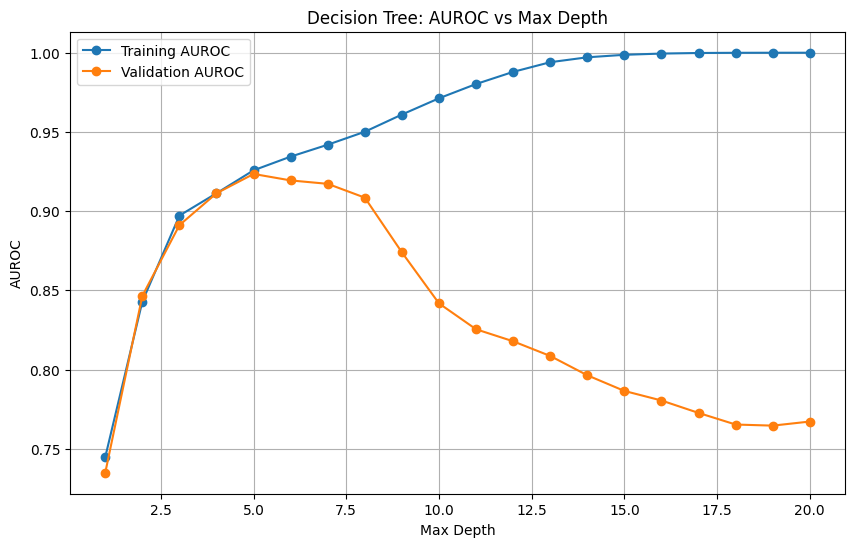

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(
    auc_df["Max Depth"],
    auc_df["Training AUROC"],
    marker="o",
    label="Training AUROC"
)

plt.plot(
    auc_df["Max Depth"],
    auc_df["Validation AUROC"],
    marker="o",
    label="Validation AUROC"
)

plt.xlabel("Max Depth")
plt.ylabel("AUROC")
plt.title("Decision Tree: AUROC vs Max Depth")

plt.legend()
plt.grid()

plt.show()

При збільшенні max_depth значення AUROC на тренувальних даних поступово зростає, оскільки модель стає складнішою. Після певної глибини різниця між train та validation AUROC збільшується, що може свідчити про перенавчання. Оптимальне значення max_depth обирається за максимальним AUROC на validation dataset.

**Завдання 5**.
1. Натренуйте модель `DecisionTree` з найкращим значенням `max_depth`, яке ви знайшли на попередній ітерації.
2. Завантажте тестові дані змагання з `test.csv`.
3. Зробіть попередню обробку даних з функцією `preprocess_new_data` з вашого модуля `process_bank_churn.py`.
4. Зробіть передбачення використовуючи цю модель на тестових даних змагання.
5. Сформуйте `submission.csv`.
6. Зробіть новий Submission на Kaggle і додайте тут скріншот Вашого скору на паблік лідерборді :)


In [ ]:
import pandas as pd

from sklearn.tree import DecisionTreeClassifier

from process_bank_churn import preprocess_new_data

# 1. Train final Decision Tree model
best_depth = 5  # значение max_depth, найденное на предыдущем шаге

model = DecisionTreeClassifier(
    max_depth=best_depth,
    random_state=42
)

model.fit(
    X_train,
    train_targets
)

# 2. Load competition test data

test_df = pd.read_csv("test.csv")


# 3. Preprocess test data
#    using already fitted scaler and encoder


X_test = preprocess_new_data(
    new_df=test_df,
    input_cols=data["input_cols"],
    scaler=data["scaler"],
    encoder=data["encoder"]
)


# 4. Make predictions
predictions = model.predict(X_test)

# 5. Create submission file


submission = pd.DataFrame(
    {
        "id": test_df["id"],
        "Exited": predictions
    }
)


# 6. Save submission.csv

submission.to_csv(
    "submission.csv",
    index=False
)

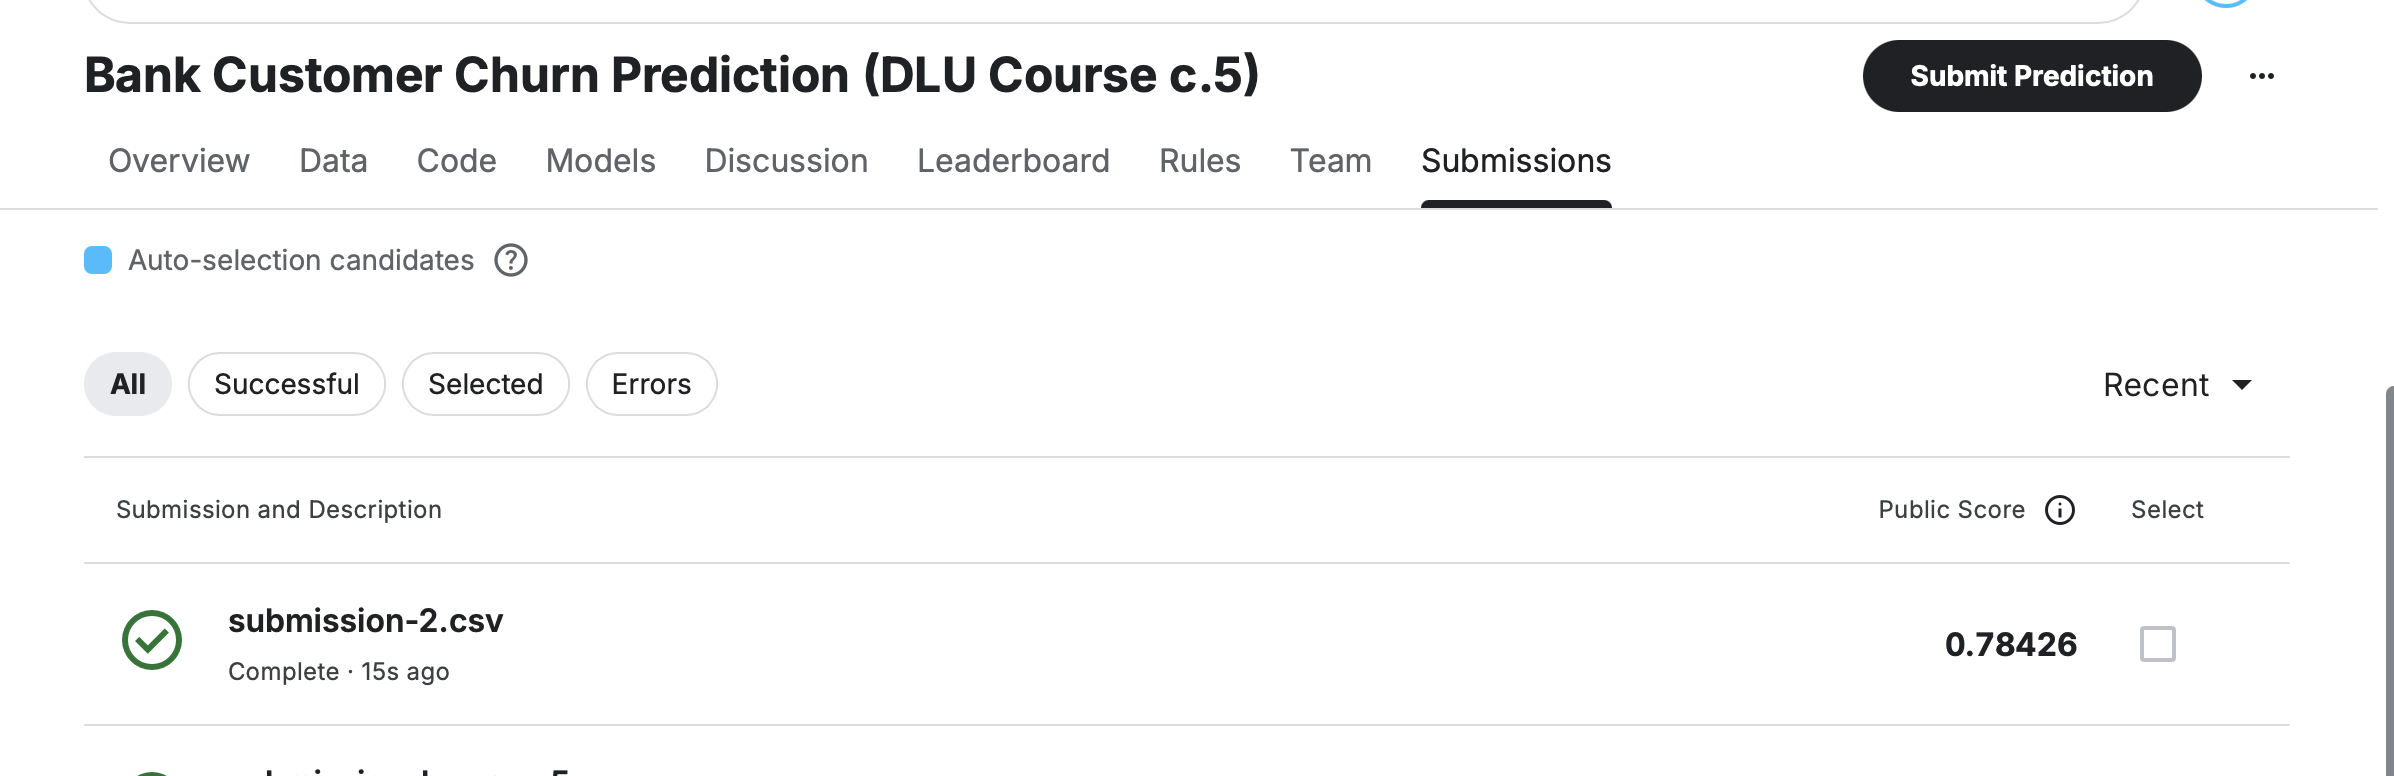